# Pairs Trading Strategy

Pairs trading is a market-neutral statistical arbitrage strategy that seeks to profit from temporary mispricing between two historically related securities. Instead of betting on overall market direction, the strategy focuses on the relative performance between two assets.

**The core idea is simple:**

If two securities have historically moved together and their price relationship diverges beyond a normal range, there is a statistical expectation that the spread will revert back to its mean. A trader can exploit this by going long the undervalued asset and short the overvalued asset simultaneously.
Because the long and short positions offset each other, pairs trading aims to reduce exposure to broad market risk and isolate relative value opportunities.

Import the libraries

In [137]:
import pandas as pd
import numpy as np
import yfinance as yf
import statsmodels.api as sm
import statsmodels
import seaborn as sns
from statsmodels.tsa.stattools import coint
from statsmodels.regression.rolling import RollingOLS
from matplotlib import pyplot as plt

np.random.seed(42)  # For reproducibility

#### Generate two random fake securities

We will model X's daily returns by drawing from a normal distribution and them perform a cumulative sum to get the value of X on each day.

<Axes: title={'center': 'Stock X Price'}>

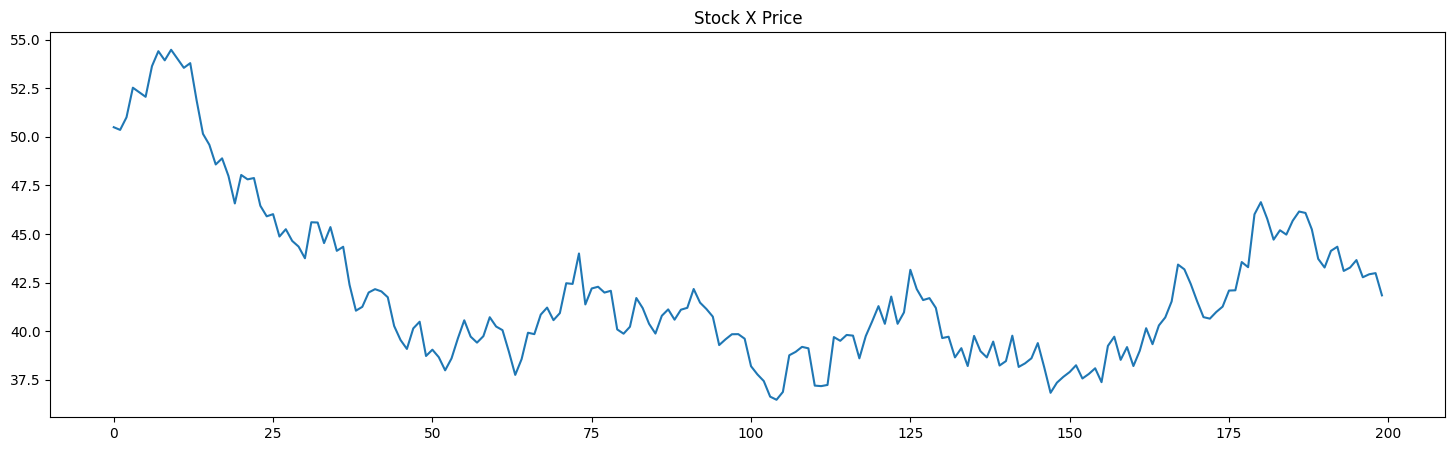

In [85]:
X_returns = np.random.normal(0, 1, 200) # Simulated returns for stock X
X = pd.Series(np.cumsum(X_returns), name='X') + 50 # Cumulative returns for stock X, then add a constant to simulate a price series in a rasonable range
X.plot(title='Stock X Price', figsize=(18, 5))

Now we will generate for Y. Remember that Y is supposed to have a deep economic link to X, so the price of Y should vary pretty similary.

To do so, we will model this by taking X, shifting it up and taking some random noise drawon from a normal distribution.

<Axes: title={'center': 'Stock X and Y Prices'}>

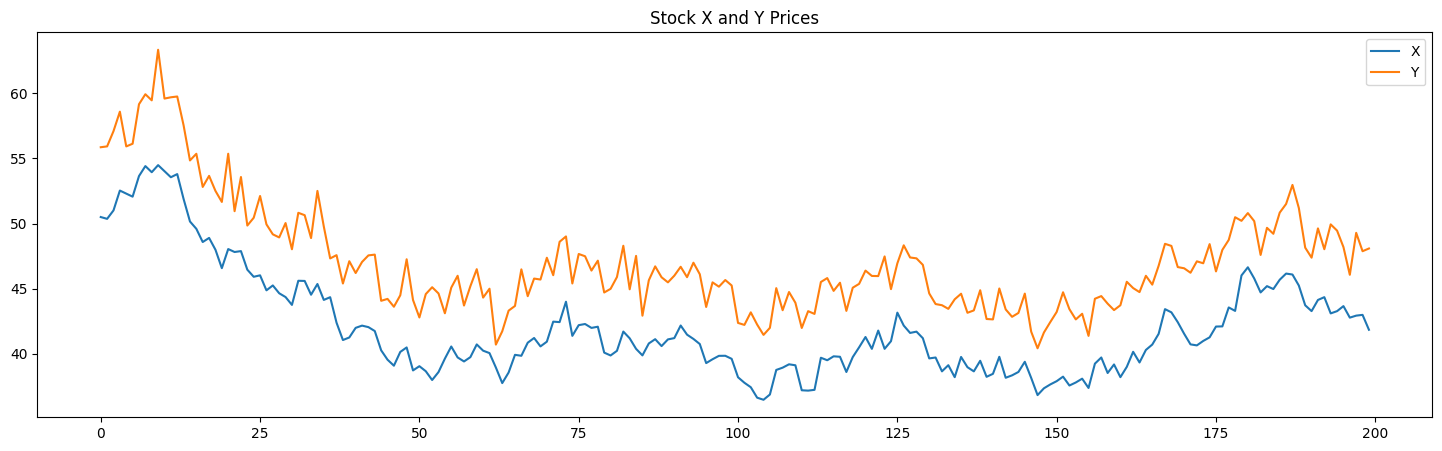

In [86]:
noise = np.random.normal(0, 1, 200) # Stock Y is highly correlated with stock X
Y = X + 5 + noise
Y.name = 'Y'
pd.concat([X, Y], axis=1).plot(title='Stock X and Y Prices', figsize=(18, 5))

#### Co-integration

Cointegration is a different form of correlation. If two timeseries are cointegrated, there is some linear combination between them that will vary around a mean. At all points in time, the combination between them is related to the same probability distribution.

We can plot the difference between the two lines X and Y, and see their looks.

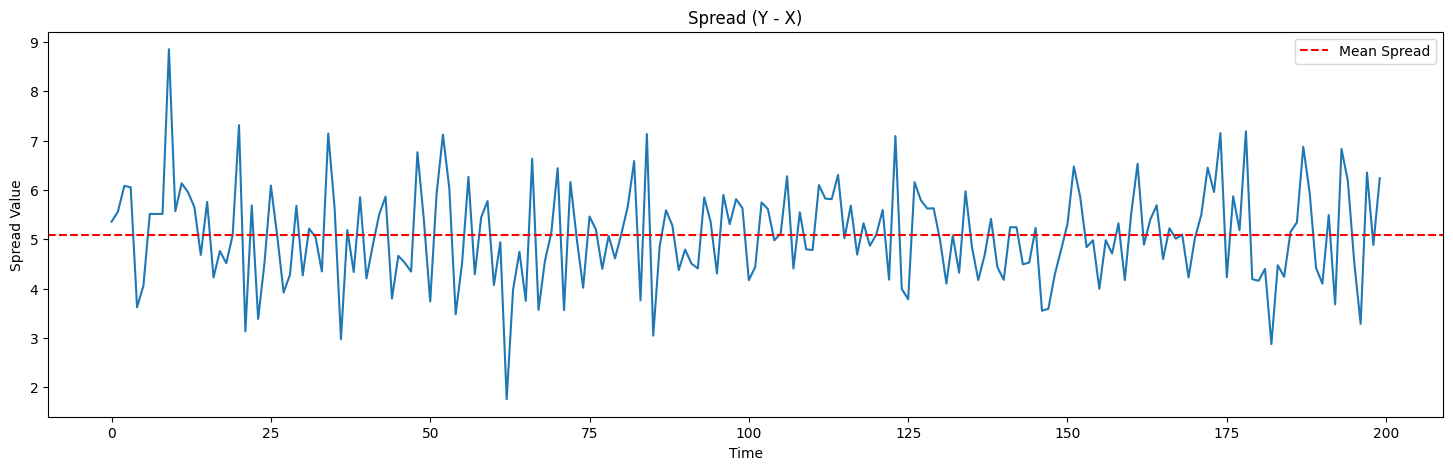

In [87]:
(Y - X).plot(title='Spread (Y - X)', figsize=(18, 5))
plt.axhline((Y - X).mean(), color='red', linestyle='--', label='Mean Spread') # Add the mean
plt.xlabel('Time')
plt.ylabel('Spread Value')
plt.legend()
plt.show()

#### Testing for Cointegration

There is a convenient test in ```statsmodel.tsa.stattools```. We should see a very low p-value as we have artificially created two series that are cointegrated as physically possible.

In [88]:
score, pvalue, _ = coint(X, Y)

if pvalue < 0.05:
    print("we have sufficient evidence to conclude that stocks are cointegrated.")
else:
    print("We do not have enough evidence of cointegration.")

print(f"Cointegration test p-value: {pvalue}")

we have sufficient evidence to conclude that stocks are cointegrated.
Cointegration test p-value: 2.1721175093859684e-25


#### Cointegration vs Correlation

Correlation measures how two variables move together in the short term. Two assets can be highly correlated yet still drift apart permanently.
Cointegration, on the other hand, captures a long-term equilibrium relationship. Even if prices wander, their spread remains mean-reverting over time.

**In short:**
> Correlation measures co-movement; cointegration measures stable long-run linkage — which is why cointegration is preferred for pairs trading.

In [89]:
correlation_val = X.corr(Y)
cointegration_val = coint(X, Y)[0]

print(f"Correlation: {correlation_val}")
print(f"Cointegration Value: {cointegration_val}")

Correlation: 0.9732556978917839
Cointegration Value: -14.130028945333606


#### Correlation without Cointegration

A simple example is two timeseries that just diverge from one another

<Axes: title={'center': 'Diverging Stock Prices'}>

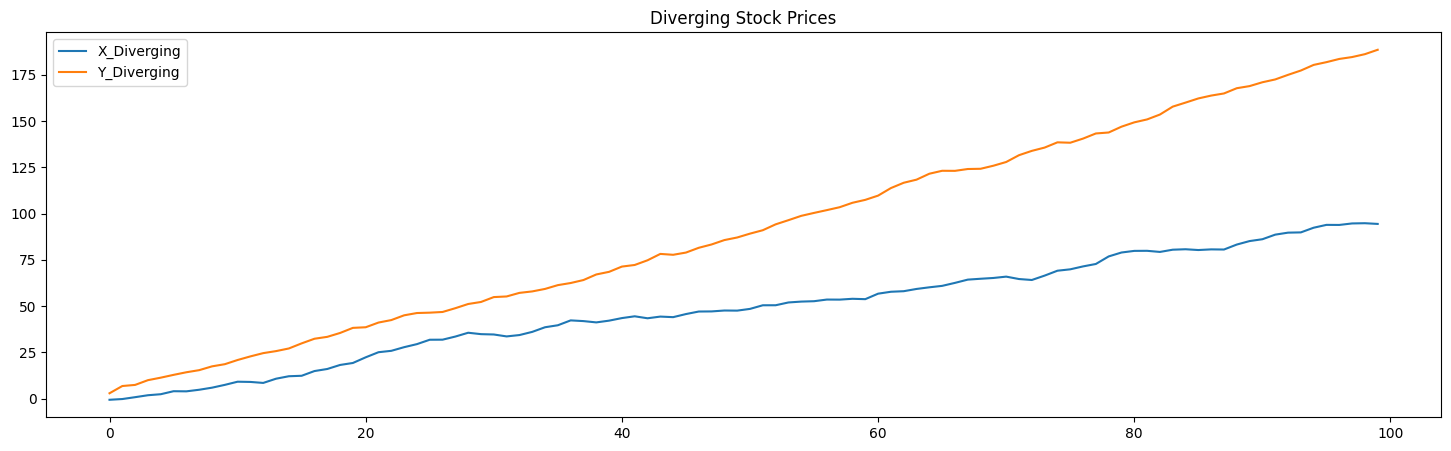

In [90]:
X_returns = np.random.normal(1, 1, 100)
Y_returns = np.random.normal(2, 1, 100)

X_diverging = pd.Series(np.cumsum(X_returns), name='X_Diverging') 
Y_diverging = pd.Series(np.cumsum(Y_returns), name='Y_Diverging')

pd.concat([X_diverging, Y_diverging], axis=1).plot(title='Diverging Stock Prices', figsize=(18, 5))

In [91]:
print(f"Correlation of Diverging Stocks: {X_diverging.corr(Y_diverging)}")
score, pvalue, _ = coint(X_diverging, Y_diverging)
print(f"Cointegration test p-value for Diverging Stocks: {pvalue}")

Correlation of Diverging Stocks: 0.9905770855470225
Cointegration test p-value for Diverging Stocks: 0.40283144260870085


Despite the very high correlation, the pair is not cointegrated. High correlation does not imply a stable long-term relationship. Therefore, the stocks may move together in the short term, but their spread is likely non-mean-reverting, making them unsuitable for a classic pairs trading strategy.

#### Cointegration without Correlation

A simple example of this is a normally distributed series and a square wave

In [92]:
Y2 = pd.Series(np.random.normal(0, 1, 1000), name='Y2') + 20
Y3 = Y2.copy()

In [93]:
Y3[0:100] = 30
Y3[100:200] = 10
Y3[200:300] = 30
Y3[300:400] = 10
Y3[400:500] = 30
Y3[500:600] = 10
Y3[600:700] = 30
Y3[700:800] = 10
Y3[800:900] = 30
Y3[900:1000] = 10

(0.0, 40.0)

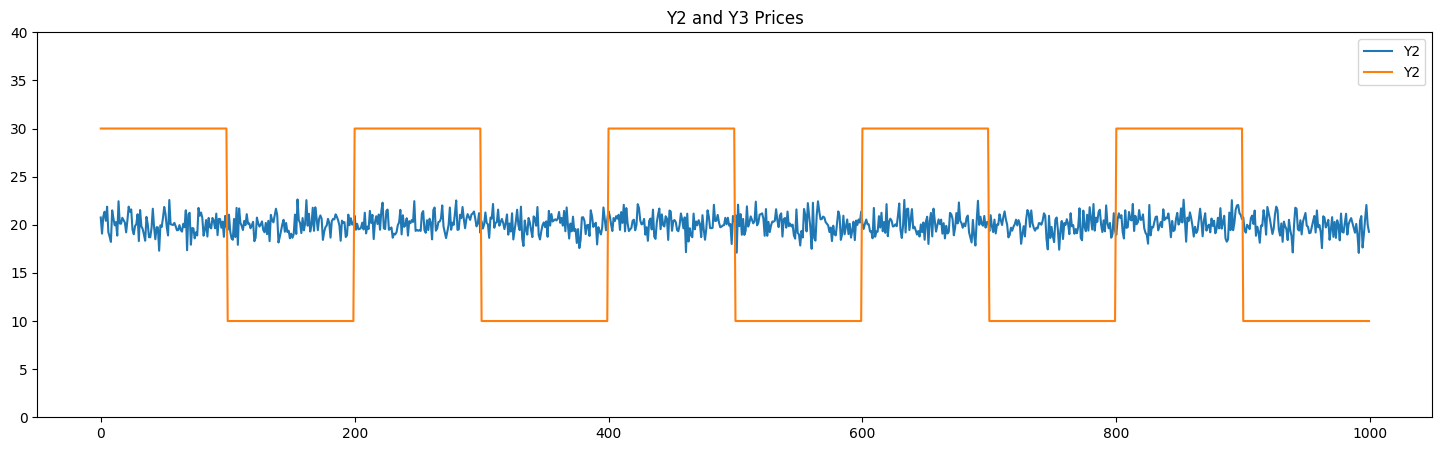

In [94]:
pd.concat([Y2, Y3], axis=1).plot(title='Y2 and Y3 Prices', figsize=(18, 5))
plt.ylim(0, 40)

In [95]:
print(f"Correlation of Diverging Stocks: {Y2.corr(Y3)}")
print(f"Cointegration P-Value of Diverging Stocks: {coint(Y2, Y3)[1]}")

Correlation of Diverging Stocks: 0.07247186667608044
Cointegration P-Value of Diverging Stocks: 0.0


This is the opposite of the typical “high correlation but no cointegration” case. The stocks do not move together in the short term, but their prices are tied by a stable long-run relationship.

#### Hedged Position

To protect against unfavorable market movements, investors often combine long and short positions. A short position profits when a security declines in value, while a long position profits when it rises. By going long on one security and short on another, an investor can reduce overall market exposure. If the broader market drops sharply, gains from the short position may help offset losses from the long position. When we hold a long position in one security and a short position in another, this is called a hedged position.

**The Core Idea**

Since related securities tend to move closer together and further apart over time, the gap between them fluctuates. Pairs trading works by maintaining a hedged position in two securities, X and Y. If both rise or fall together, the overall position is largely neutral. The objective is to profit from changes in the spread between them as it reverts toward its historical average. When X and Y diverge significantly, we might short the relatively expensive asset and go long the relatively cheap one. When they converge again, positions can be reversed accordingly.

- Going Long the Spread
> This occurs when the spread is narrow and expected to widen. The trade involves buying Y and shorting X.

- Going Short the Spread
> This occurs when the spread is wide and expected to shrink. The trade involves shorting Y and buying X.

The goal is to take a position on the spread itself rather than on overall market direction. By hedging, we reduce sensitivity to broader market movements and isolate the relative pricing relationship between the two securities.

--- 

**Identifying Suitable Pairs**

To implement this strategy, start with securities that may have a stable long-term relationship and test for cointegration. Running tests on every possible pair can introduce multiple comparisons bias, leading to false positives. One method is to compute cointegration statistics for all pairs and identify those with p-values below 0.05.

##### Warning: Multiple Comparisons Bias
When many statistical tests are conducted, some will appear significant purely by chance. For example, if 100 independent tests are run, roughly five may produce p-values below 0.05 even if no true relationship exists. Since testing all possible pairs involves 
$n(n-1)/2$ comparisons, the likelihood of false positives increases. In practice, a secondary verification step is recommended, or alternatively, test only a small set of carefully selected candidate pairs to reduce this bias.

In [96]:
def find_cointegrated_pairs(data):
  n = data.shape[1]
  score_matrix = np.zeros((n, n))
  pvalue_matrix = np.ones((n, n))
  keys = data.columns
  pairs = []
  
  for i in range(n):
    for j in range(i+1, n):
      stock1 = data[keys[i]]
      stock2 = data[keys[j]]
      score, pvalue, _ = coint(stock1, stock2)
      score_matrix[i, j] = score
      pvalue_matrix[i, j] = pvalue
            
      if pvalue < 0.05: # Threshold for cointegration
        pairs.append((keys[i], keys[j]))
    
  return score_matrix, pvalue_matrix, pairs

#### Looking for Cointegrated Pairs of Alternative Energy Securities

We will start by defining the list of securities that we want to look through and for that, we will get the pricing data for each of these assets for the year of 2014

**Note**

We will include the market in our data as the market drives the movement of many securities that you often times might find two seemingly cointegrated securities but in reality they are not cointegrated and just both cointegrated with the markets instead. This is known as a confounding variable and it is important to check for market involvement in any relationship you find.

In [107]:
ticker_symbols = ["NEE","CWEN","AQN","FCEL","BE","BEPC", "SPY"]
prices_df = yf.download(ticker_symbols, start='2022-01-01', end='2023-01-01')['Close']
prices_df.head()

/var/folders/5v/9xrz7nmd29s2z029pvbqs8r00000gn/T/ipykernel_15478/497124135.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  prices_df = yf.download(ticker_symbols, start='2022-01-01', end='2023-01-01')['Close']
[*********************100%***********************]  7 of 7 completed


Ticker,AQN,BE,BEPC,CWEN,FCEL,NEE,SPY
Date,,,,,,,
2022-01-03,11.571042,22.139999,30.673950,28.959002,173.399994,82.245995,451.875153
2022-01-04,11.522660,21.549999,30.146822,28.499981,176.399994,81.366638,451.723816
2022-01-05,11.385582,20.209999,29.310106,27.356434,159.600006,80.514229,443.049744
2022-01-06,11.353330,19.469999,28.557060,27.509438,154.199997,76.960930,442.633484
2022-01-07,11.433964,19.250000,29.059097,27.267849,153.000000,77.535187,440.883514


Plot a headmap to show the cointegration test between each pair of stocks. Only show the values in the upper diagonal of the heatmap

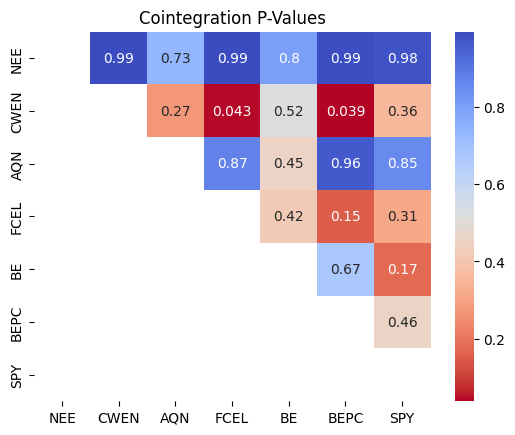

[('BE', 'CWEN'), ('BE', 'NEE')]


In [115]:
scores, pvalues, pairs = find_cointegrated_pairs(prices_df)
sns.heatmap(pvalues, xticklabels=ticker_symbols, yticklabels=ticker_symbols, cmap='coolwarm_r', annot=True, mask = (pvalues >= 0.9999))
plt.title('Cointegration P-Values')
plt.show()
print(pairs)

From the above plot and results, it seems like *CWEN* and *BE* are cointegrated, So are *BE* amd *NEE*. Before proceeding further, we need to look at their prices so as to be sure that there is nothing strange.

In [116]:
s1 = prices_df['BE']
s2 = prices_df['CWEN']
s3 = prices_df['NEE']

In [117]:
score_s1_s2, pvalue_s1_s2, _ = coint(s1, s2)
score_s1_s3, pvalue_s1_s3, _ = coint(s1, s3)

print(f"Cointegration p-value for BE and CWEN: {pvalue_s1_s2}")
print(f"Cointegration p-value for BE and NEE: {pvalue_s1_s3}")

Cointegration p-value for BE and CWEN: 0.04257189896035016
Cointegration p-value for BE and NEE: 0.038618516417009155


Plot the spread of the two sets of timeseries. We will use linear regression to calculate a coefficient for their linear combination.

In [119]:
def linear_combination(series1, series2, ticker):
  S1 = sm.add_constant(series1)
  S2 = series2
  model = sm.OLS(S2, S1).fit()
  S1 = S1[ticker]
  b = model.params[ticker]
  spread = S2 - b * S1
  return spread

def spread_plot(spread, title):
  spread.plot(title=title, figsize=(18, 5))
  plt.axhline(spread.mean(), color='red', linestyle='--', label='Mean Spread')
  plt.xlabel('Time')
  plt.ylabel('Spread Value')
  plt.legend()
  plt.show()

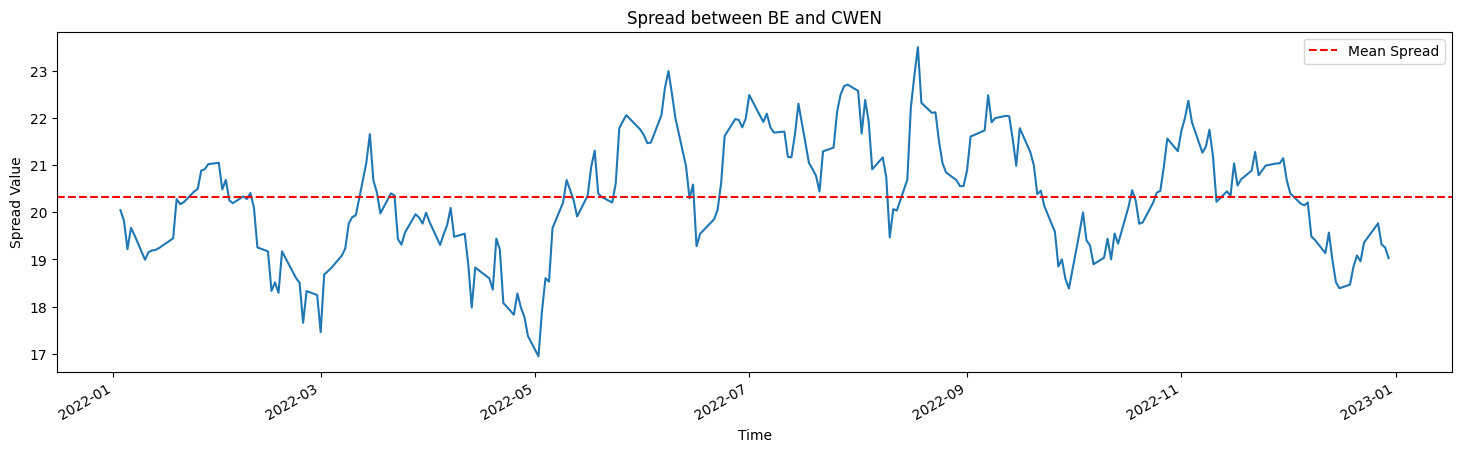

In [120]:
spread_s1_s2 = linear_combination(s1, s2, 'BE')
spread_plot(spread_s1_s2, 'Spread between BE and CWEN')

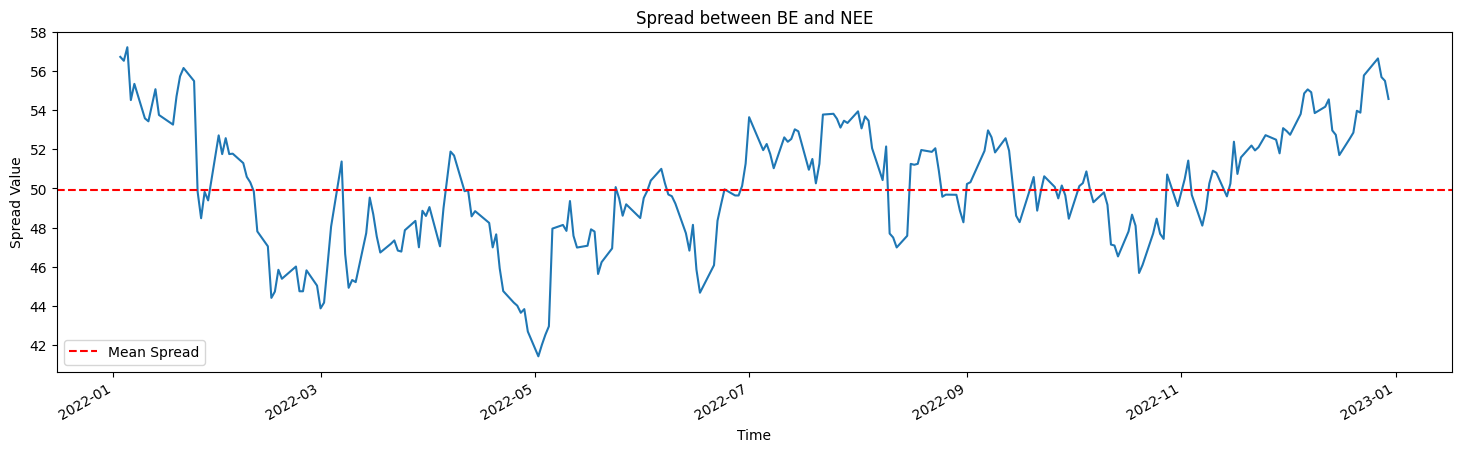

In [121]:
spread_s1_s3 = linear_combination(s1, s3, 'BE')
spread_plot(spread_s1_s3, 'Spread between BE and NEE')

Alternatively, we can examine the ratio between the two sets of series as follow

In [122]:
ratio_s1_s2 = s1 / s2
ratio_s1_s3 = s1 / s3

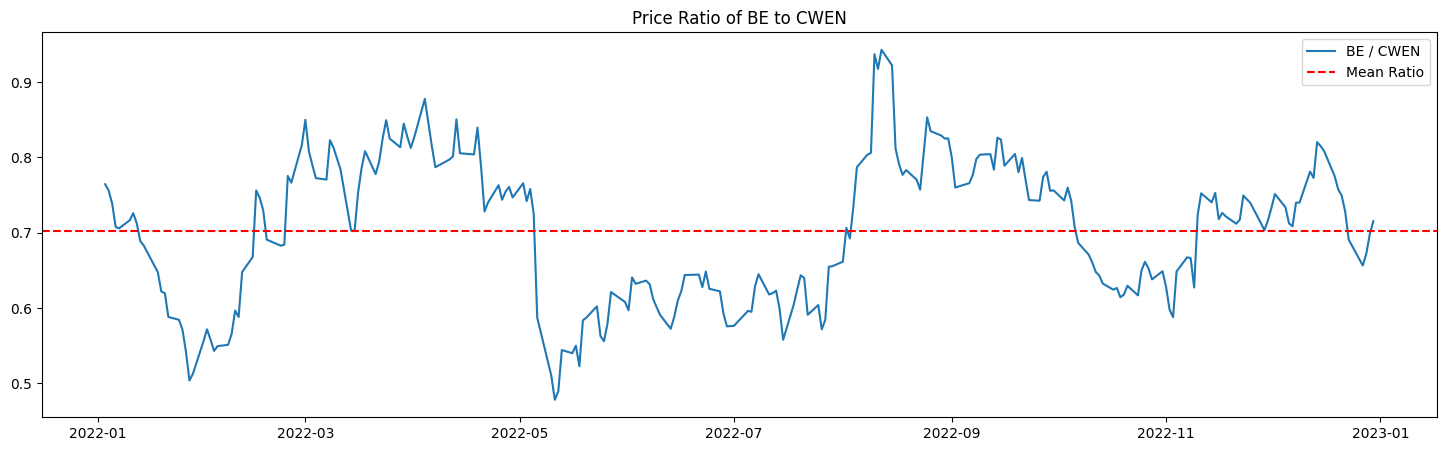

In [125]:
plt.figure(figsize=(18, 5))
plt.plot(ratio_s1_s2, label='BE / CWEN')
plt.axhline(ratio_s1_s2.mean(), color='red', linestyle='--', label='Mean Ratio')
plt.title('Price Ratio of BE to CWEN')
plt.legend()
plt.show()

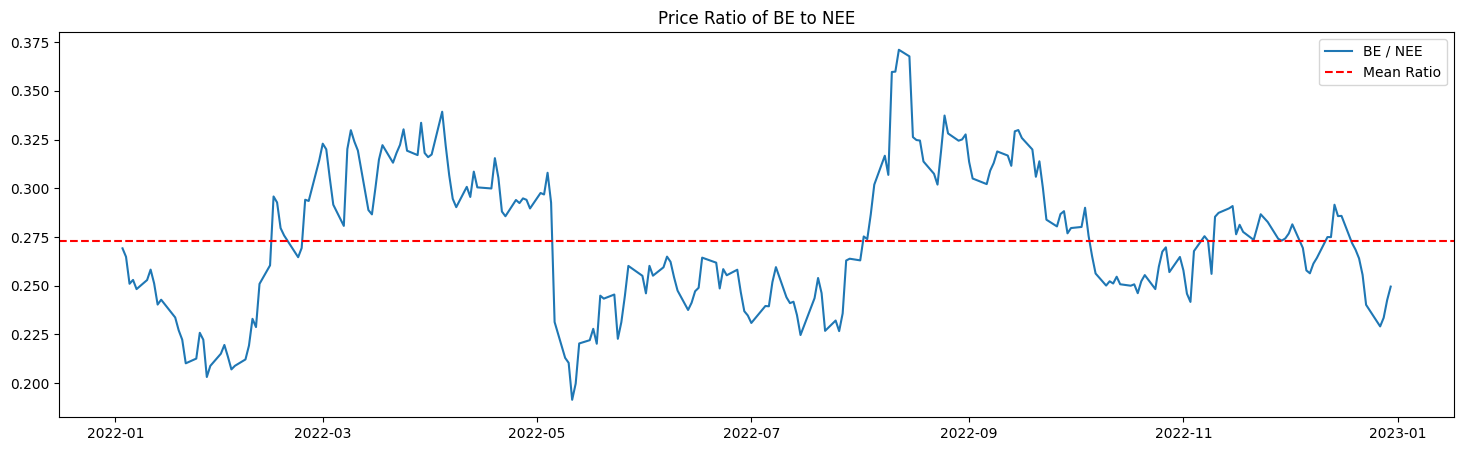

In [127]:
plt.figure(figsize=(18, 5))
plt.plot(ratio_s1_s3, label='BE / NEE')
plt.axhline(ratio_s1_s3.mean(), color='red', linestyle='--', label='Mean Ratio')
plt.title('Price Ratio of BE to NEE')
plt.legend()
plt.show()

Analyzing the price ratio of a trading pair is a classic approach in pairs trading. This works partly because of how we assume stock prices behave—typically following a log-normal distribution. Taking a price ratio is effectively taking a linear combination of the returns, since prices are exponentiated returns. However, calculating the exact ratio using linear regression can be cumbersome and impractical.

Instead, we simplify by calculating the spread between cointegrated stocks via linear regression. While this is straightforward for cointegrated pairs, it may not work for pairs that are not cointegrated. There are other methods to model relationships in pairs trading.

#### Caution!!!

In our example, the absolute spread has limited statistical value. It is more useful to normalize it as a z-score, giving the data some scale. ⚠️ However, this assumes an underlying distribution—usually normal. Under a normal distribution, about 84% of spread values would fall below a certain threshold. In reality, financial data is often far from normal, exhibiting fat tails and extreme values. Assuming normality in such cases can distort the model and lead to significant losses.

In [129]:
def z_score(series):
  return (series - series.mean()) / series.std()

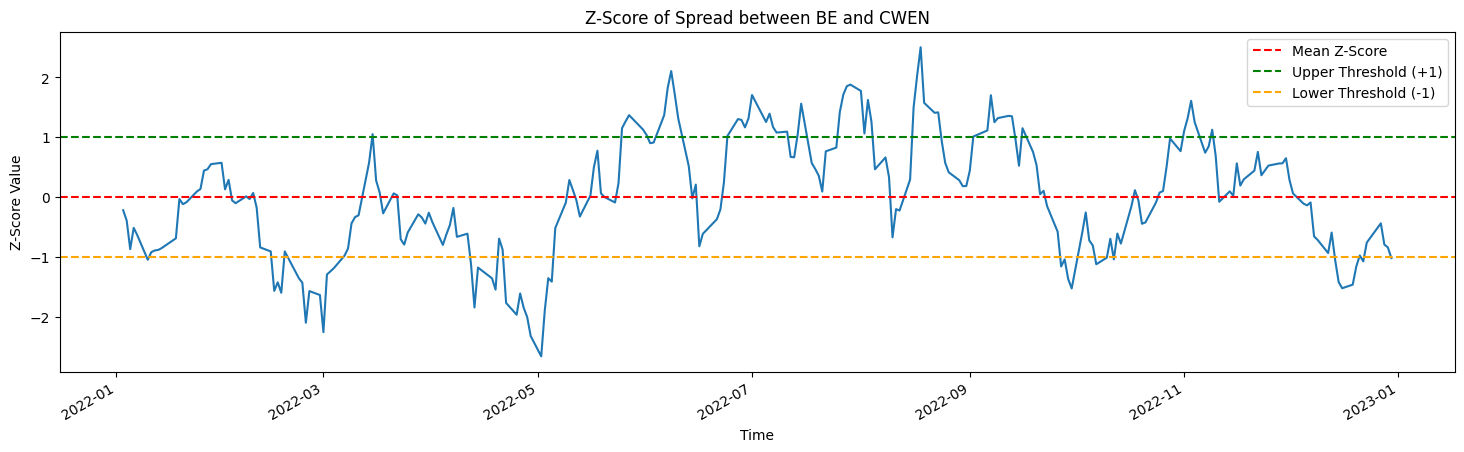

In [133]:
z_score(spread_s1_s2).plot(title='Z-Score of Spread between BE and CWEN', figsize=(18, 5))
plt.axhline(z_score(spread_s1_s2).mean(), color='red', linestyle='--', label='Mean Z-Score')
plt.axhline(1, color='green', linestyle='--', label='Upper Threshold (+1)')
plt.axhline(-1, color='orange', linestyle='--', label='Lower Threshold (-1)')
plt.xlabel('Time')
plt.ylabel('Z-Score Value')
plt.legend()
plt.show()

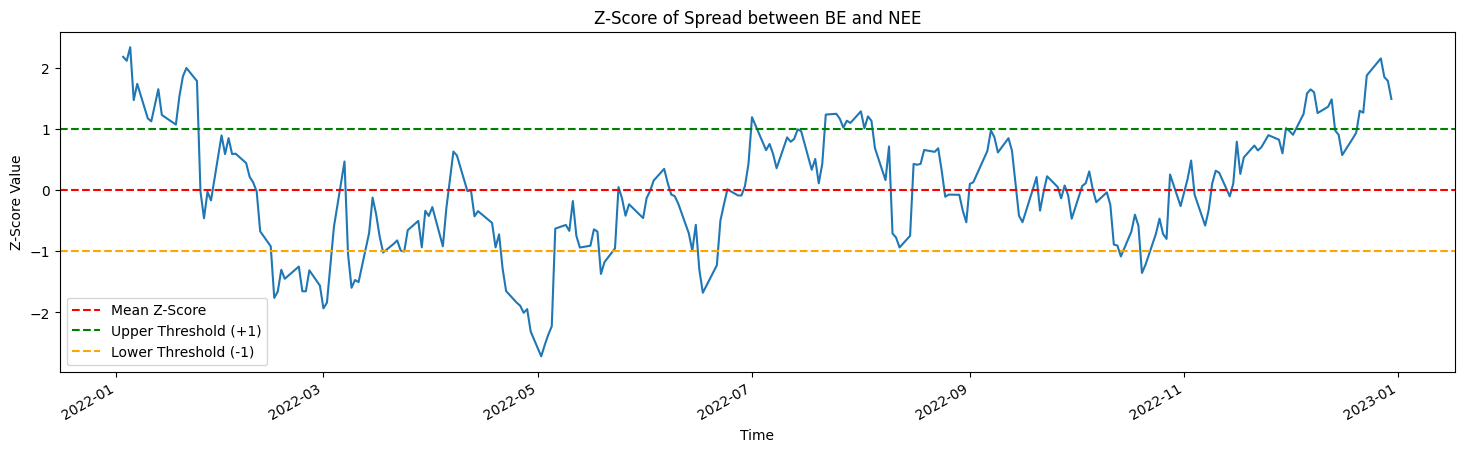

In [134]:
z_score(spread_s1_s3).plot(title='Z-Score of Spread between BE and NEE', figsize=(18, 5))
plt.axhline(z_score(spread_s1_s3).mean(), color='red', linestyle='--', label='Mean Z-Score')
plt.axhline(1, color='green', linestyle='--', label='Upper Threshold (+1)')
plt.axhline(-1, color='orange', linestyle='--', label='Lower Threshold (-1)')
plt.xlabel('Time')
plt.ylabel('Z-Score Value')
plt.legend()
plt.show()

#### Simple Pairs Trading Strategy

A simple strategy would be: 
- Go "Long" the spread whenever the z-score is below -1.0. 
- Go "Short" the spread when the z-score is above 1.0. 
- Exit positions when the z-score approaches zero. 

This is just the tip of the iceberg, and only a very simplistic example to illustrate the concepts. In practice you would want to compute a more optimal weighting for how many shares to hold for S1 and S2. Some additional resources on pairs trading are listed at the end of this notebook.Trading using constantly updating statistics: In general taking a statistic over your whole sample size can be bad. For example, if the market is moving up, and both securities with it, then your average price over the last 3 years may not be representative of today. For this reason traders often use statistics that rely on rolling windows of the most recent data.

**Moving Average** 

A moving average is just an average over the last n datapoints for each given time. It will be undefined for the first n datapoints in our series. Shorter moving averages will be more jumpy and less reliable, but respond to new information quickly. Longer moving averages will be smoother, but take more time to incorporate new information. We also need to use a rolling beta, a rolling estimate of how our spread should be calculated, in order to keep all of our parameters up to date.

We will be using the example of BE and CWEN

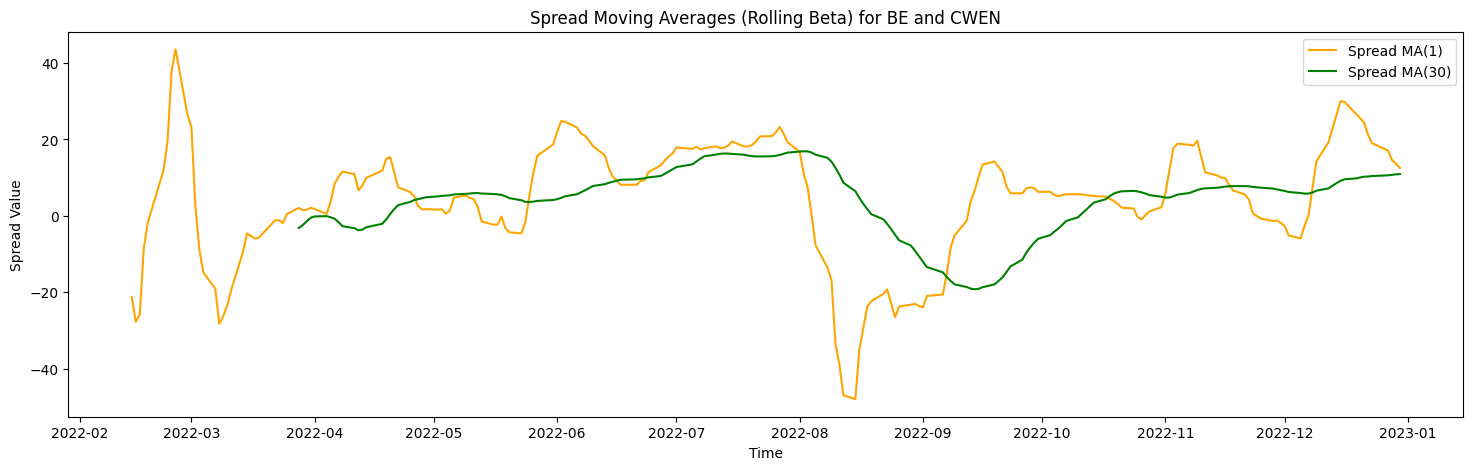

In [149]:
s1_ticker = 'BE'
s2_ticker = 'CWEN'

# Compute the rolling beta of s2 on s1 using a 30-day window
X = sm.add_constant(s2)
model = RollingOLS(s1, X, window=30)
rres = model.fit()
rolling_beta = rres.params[s2_ticker]

spread = s2 - rolling_beta * s1
spread.name = 'Rolling Beta Spread'

# Get the 1 day MA of the price spread
spread_mavg1 = spread.rolling(window=1).mean()
spread_mavg1.name = 'Spread MA(1)'

# Get the 30 day MA of the price spread
spread_mavg30 = spread.rolling(window=30).mean()
spread_mavg30.name = 'Spread MA(30)'

# Plot the data
plt.figure(figsize=(18, 5))
plt.plot(spread_mavg1, label='Spread MA(1)', color='orange')
plt.plot(spread_mavg30, label='Spread MA(30)', color='green')
plt.legend()
plt.title(f'Spread Moving Averages (Rolling Beta) for {s1_ticker} and {s2_ticker}')
plt.xlabel('Time')
plt.ylabel('Spread Value')
plt.show()


We can use the moving averages to compute the z-score of the spread at each given time. This will tell us how extreme the spread is and whether it is a good idea to enter a position at this time. Let us take a look at the z-score now.

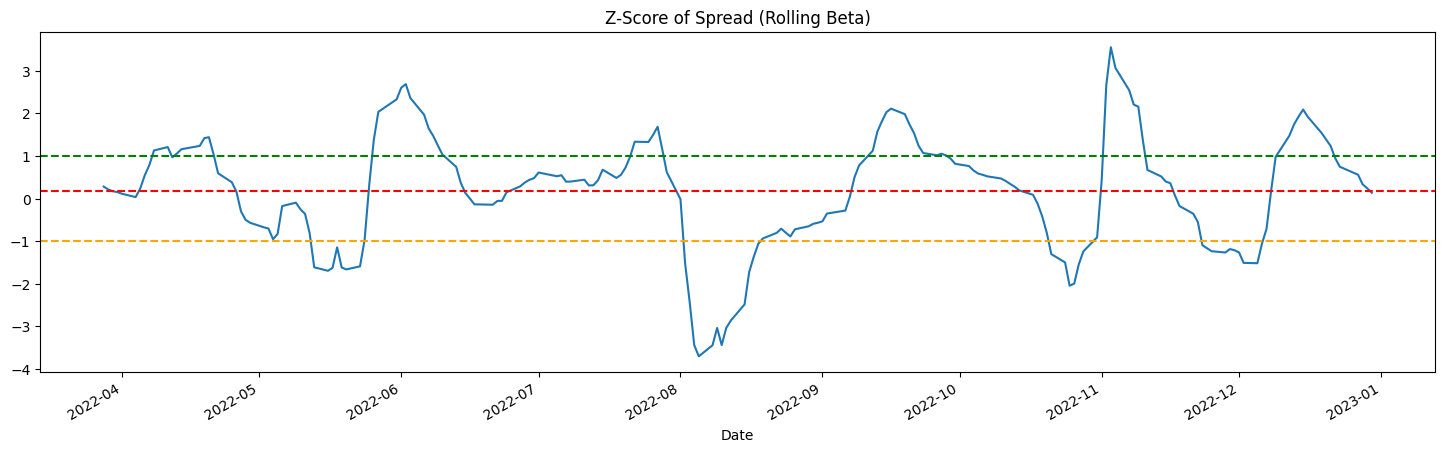

In [150]:
std_30 = spread.rolling(window=30).std()
std_30.name = 'Spread Rolling Std Dev (30)'

# Compute the z-score of the spread using the 30-day rolling mean and std
zscore_30_1 = (spread_mavg1 - spread_mavg30) / std_30
zscore_30_1.name = 'Z-Score of Spread (Rolling Beta)'
zscore_30_1.plot(title='Z-Score of Spread (Rolling Beta)', figsize=(18, 5))
plt.axhline(zscore_30_1.mean(), color='red', linestyle='--', label='Mean Z-Score')
plt.axhline(1, color='green', linestyle='--', label='Upper Threshold (+1)')
plt.axhline(-1, color='orange', linestyle='--', label='Lower Threshold (-1)')

Plot the prices scaled down along with the negative z-score. We will just divide the stock prices by 10 to make it easier for viewing on the plot

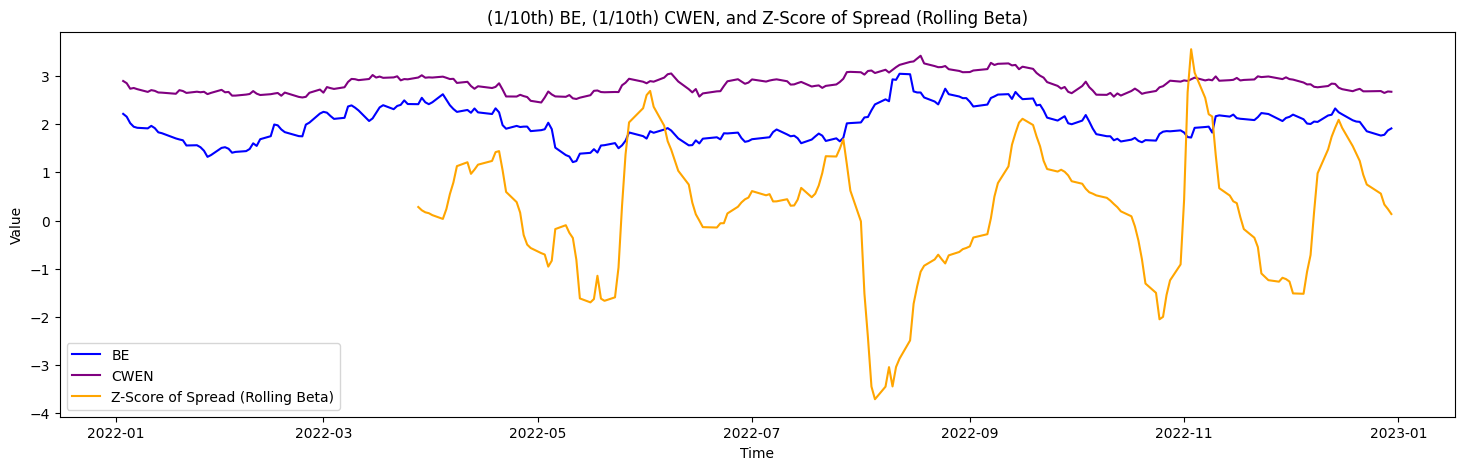

In [156]:
factor = 10

plt.figure(figsize=(18, 5))
plt.plot(s1.index, s1 / factor, label='BE', color='blue')
plt.plot(s2.index, s2 / factor, label='CWEN', color='purple')
plt.plot(zscore_30_1.index, zscore_30_1, label='Z-Score of Spread (Rolling Beta)', color='orange')
plt.legend()
plt.title(f'(1/{factor}th) BE, (1/{factor}th) CWEN, and Z-Score of Spread (Rolling Beta)')
plt.xlabel('Time')
plt.ylabel('Value')
plt.show()

#### Implementing our Pairs Trading Strategy

To recap, our simple strategy would be to:
- Go "Long" the spread whenever the z-score is below -1.0. 
- Go "Short" the spread when the z-score is above 1.0. 
- Exit positions when the z-score approaches zero. 

Note for this, we will be longing and shorting BOTH pairs (not Long/Short either one). Though pairs trading involves longing and shorting the individual pairs separately, this strategy makes use of trading the pairs and implementing a LONG/SHORT portfolio where we will only either long or short both pairs when the zscore spread condition is met.

In [206]:
def z_score_spread_trading_strategy(stocks_df, pair_1_ticker, pair_2_ticker):
  df = pd.DataFrame()
  df['date'] = stocks_df.index
  df[pair_1_ticker] = list(stocks_df[pair_1_ticker])
  df[pair_2_ticker] = list(stocks_df[pair_2_ticker])
  
  # Compute the spread and z-score
  s1_ticker = 'BE'
  s2_ticker = 'CWEN'
  s1 = stocks_df[s1_ticker]
  s2 = stocks_df[s2_ticker]
  
  # Compute the rolling beta of s2 on s1 using a 30-day window
  X = sm.add_constant(s2)
  model = RollingOLS(s1, X, window=30)
  rres = model.fit()
  rolling_beta = rres.params[s2_ticker]

  spread = s2 - rolling_beta * s1
  
  # Get the 1 day MA of the price spread
  spread_mavg1 = spread.rolling(window=1).mean()
  
  # Get the 30 day MA of the price spread
  spread_mavg30 = spread.rolling(window=30).mean()
  
  # Get the 30 day rolling std of the price spread
  std_30 = spread.rolling(window=30).std()

  # Compute the z-score of the spread using the 30-day rolling mean and std
  zscore_30_1 = (spread_mavg1 - spread_mavg30) / std_30
  
  # Append the z-score to the dataframe
  df['zscore'] = list(zscore_30_1)
  
  # Compute the daily returns of the two stocks
  df['return_' + pair_1_ticker] = df[pair_1_ticker].pct_change()
  df['return_' + pair_2_ticker] = df[pair_2_ticker].pct_change()
  
  # Compute the signals based on the z-score
  df['signal'] = 0
  df.loc[df['zscore'] > 1, 'signal'] = -1
  df.loc[df['zscore'] < -1, 'signal'] = 1
  
  # Compute the strategy returns which is the return of the long and short positions based on the signals
  df['strategy_return'] = df['signal'].shift(1) * (df['return_' + pair_1_ticker] +  df['return_' + pair_2_ticker])
  df['cumulative_strategy_return'] = (1 + df['strategy_return']).cumprod() - 1
  
  return df

def performance_metrics(strategy_df, stocks_df, benchmark_ticker):
  total_return = strategy_df['cumulative_strategy_return'].iloc[-1]
  annualized_return = (1 + total_return) ** (252 / len(strategy_df)) - 1
  annualized_volatility = strategy_df['strategy_return'].std() * np.sqrt(252)
  sharpe_ratio = annualized_return / annualized_volatility if annualized_volatility != 0 else np.nan
  
  metrics_df = pd.DataFrame({
    'Strategy': [total_return, annualized_return, annualized_volatility, sharpe_ratio]
  }, index=['Total Return', 'Annualized Return', 'Annualized Volatility', 'Sharpe Ratio'])
  
  # Add the benchmark performance for comparison
  benchmark_returns = stocks_df[benchmark_ticker].pct_change()
  benchmark_total_return = (1 + benchmark_returns).prod() - 1
  benchmark_annualized_return = (1 + benchmark_total_return) ** (252 / len(strategy_df)) - 1
  benchmark_annualized_volatility = benchmark_returns.std() * np.sqrt(252)
  benchmark_sharpe_ratio = benchmark_annualized_return / benchmark_annualized_volatility if benchmark_annualized_volatility != 0 else np.nan
  
  # Append benchmark metrics to the metrics_df
  metrics_df['Benchmark'] = [benchmark_total_return, benchmark_annualized_return, benchmark_annualized_volatility, benchmark_sharpe_ratio]
  
  return metrics_df

In [207]:
be_cwen_pairs_trading_strat = z_score_spread_trading_strategy(prices_df, 'BE', 'CWEN')

Plot the returns and compute the performance metrics of the strategy

Text(0, 0.5, 'Cumulative Return')

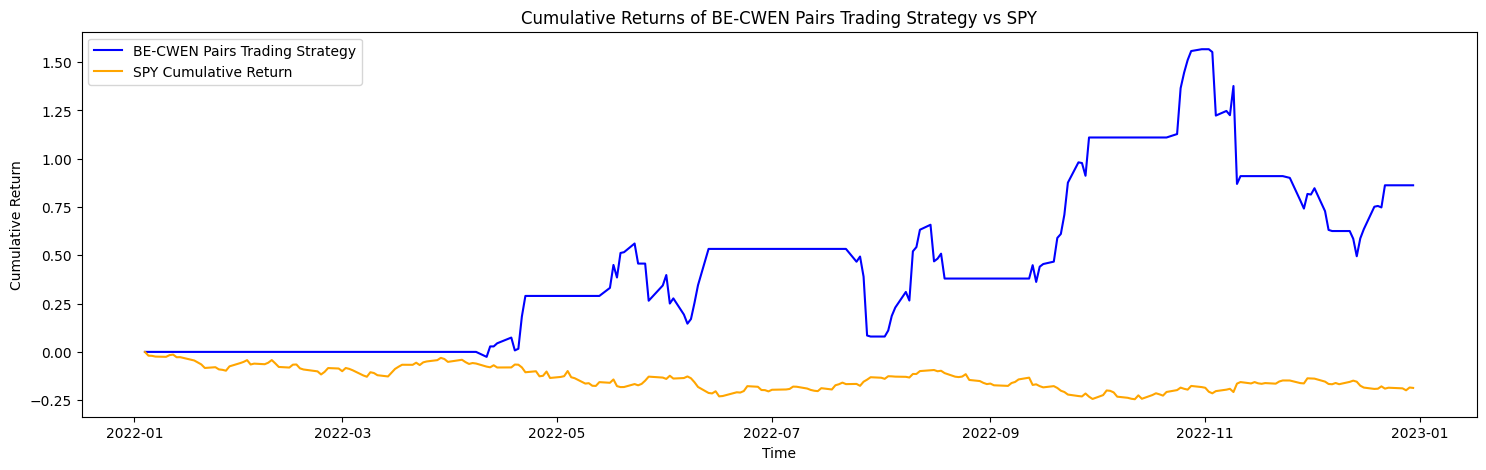

In [208]:
# Plot the cumulative returns of the strategy
plt.figure(figsize=(18, 5))
plt.plot(be_cwen_pairs_trading_strat['date'], be_cwen_pairs_trading_strat['cumulative_strategy_return'], label='BE-CWEN Pairs Trading Strategy', color='blue')
plt.plot(be_cwen_pairs_trading_strat['date'], (1 + prices_df['SPY'].pct_change()).cumprod() - 1, label='SPY Cumulative Return', color='orange')
plt.legend()
plt.title('Cumulative Returns of BE-CWEN Pairs Trading Strategy vs SPY')
plt.xlabel('Time')
plt.ylabel('Cumulative Return')

**Performance Metrics**

In [209]:
metrics = performance_metrics(be_cwen_pairs_trading_strat, prices_df, 'SPY')
metrics

,Strategy,Benchmark
Total Return,0.862426,-0.186464
Annualized Return,0.867046,-0.187133
Annualized Volatility,0.658161,0.242828
Sharpe Ratio,1.317378,-0.770637
